# TechMind — Data Science Pipeline

**Notebook de documentación y exploración** del modelo de clasificación de contenidos técnicos.

Este notebook replica el pipeline de `expand_and_train.py` de forma documentada y reproducible,
e incorpora **validación cruzada estratificada (K-Fold)** para obtener métricas más robustas.

| Campo | Detalle |
|---|---|
| Dataset | `data/raw/contenidos_tecnicos.csv` |
| Categorías | Backend, Frontend, DevOps, Mobile, Cloud, Data Science, Bases de Datos, Seguridad |
| Vectorización | TF-IDF sublineal, n-gramas 1-3, 6 000 features |
| Modelo | Ensamble calibrado (LR + LinearSVC + ComplementNB) |
| Evaluación | Hold-out 80/20 + Cross-Validation Estratificada K=5 |


## 1. Importaciones

In [1]:
import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score


## 2. Carga del dataset

El CSV fue generado y ampliado por `expand_and_train.py`. Cargamos dinámicamente
para que el notebook siempre refleje el estado actual del archivo.


In [3]:
BASE_DIR = Path(".").resolve().parent
CSV_PATH = BASE_DIR / "data" / "raw" / "contenidos_tecnicos.csv"

df = pd.read_csv(CSV_PATH)
print(f"Registros cargados: {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.head()


Registros cargados: 259
Columnas: ['titulo', 'texto', 'categoria']


,titulo,texto,categoria
0,Introducción a Spring Boot,En este contenido se presentan los conceptos b...,Backend
1,Arquitectura de microservicios,Se describen los principios de diseño de micro...,Backend
2,Consultas avanzadas en SQL,"Tutorial sobre subconsultas, joins y funciones...",Bases de Datos
3,Pipelines de Scikit-Learn,Se explica cómo construir pipelines reproducib...,Data Science
4,Hooks de React explicados,"Se explican los hooks useState, useEffect y us...",Frontend


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Información general

In [4]:
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print(f"\nDuplicados: {df.duplicated().sum()}")


titulo       object
texto        object
categoria    object
dtype: object

Valores nulos por columna:
titulo       0
texto        0
categoria    0
dtype: int64

Duplicados: 0


### 3.2 Distribución de categorías

/var/folders/vz/strzpqx976j7mh42rs8lqcq40000gn/T/ipykernel_51764/586708745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y="categoria", order=order, palette="viridis")


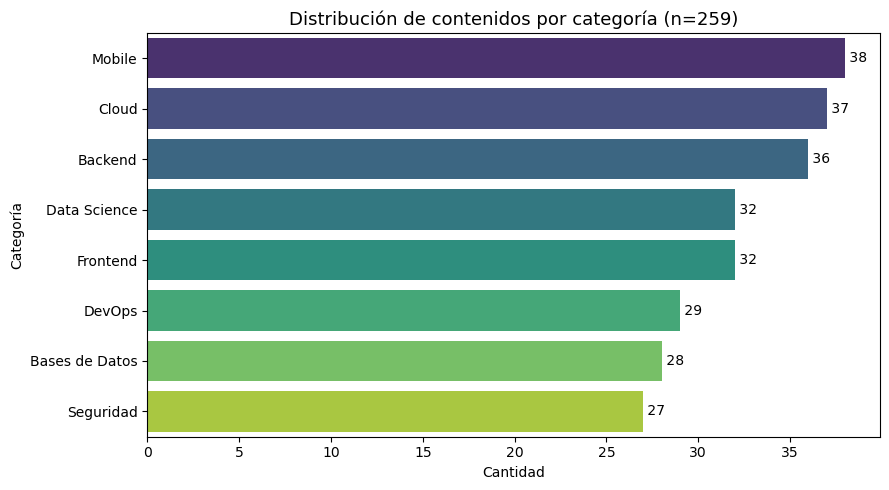

categoria
Mobile            38
Cloud             37
Backend           36
Data Science      32
Frontend          32
DevOps            29
Bases de Datos    28
Seguridad         27
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(9, 5))
order = df["categoria"].value_counts().index
ax = sns.countplot(data=df, y="categoria", order=order, palette="viridis")
plt.title(f"Distribución de contenidos por categoría (n={len(df)})", fontsize=13)
plt.xlabel("Cantidad")
plt.ylabel("Categoría")
for p in ax.patches:
    ax.annotate(f" {int(p.get_width())}",
                (p.get_width(), p.get_y() + p.get_height() / 2),
                va="center", fontsize=10)
plt.tight_layout()
plt.show()
print(df["categoria"].value_counts())


### 3.3 Distribución de longitud del texto

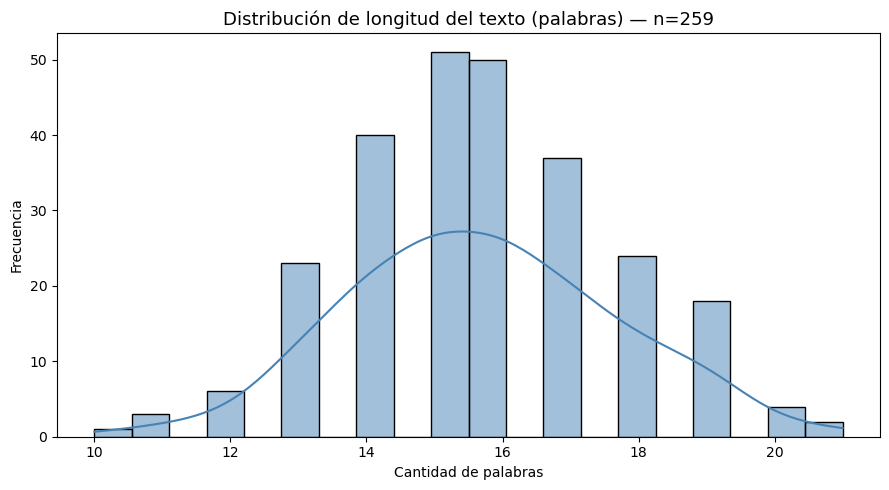

count    259.00
mean      15.69
std        1.98
min       10.00
25%       14.00
50%       16.00
75%       17.00
max       21.00
Name: longitud_texto, dtype: float64


In [6]:
df["longitud_texto"] = df["texto"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(9, 5))
sns.histplot(df["longitud_texto"], bins=20, kde=True, color="steelblue")
plt.title(f"Distribución de longitud del texto (palabras) — n={len(df)}", fontsize=13)
plt.xlabel("Cantidad de palabras")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
print(df["longitud_texto"].describe().round(2))


## 4. Preprocesamiento de texto

Combinamos `titulo` + `texto` en un único campo antes de limpiar
(el título aporta términos muy discriminantes, como indica la mejora implementada en `expand_and_train.py`).

La limpieza aplica:
- Minúsculas
- Remoción de puntuación y caracteres especiales
- Eliminación de stopwords en español (NLTK con fallback manual) + ruido técnico genérico
- Filtrado de tokens de longitud ≤ 2


In [7]:
# Stopwords: NLTK con fallback robusto (idéntico a expand_and_train.py)
try:
    import nltk
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    STOPWORDS_ES = set(stopwords.words('spanish'))
    print(f"✅ NLTK Stopwords cargadas ({len(STOPWORDS_ES)} palabras).")
except Exception:
    STOPWORDS_ES = {
        "el","la","los","las","un","una","unos","unas","de","del","al","a","en","y","o",
        "que","con","para","por","se","su","sus","es","son","este","esta","estos","estas",
        "como","más","mas","muy","entre","sobre","desde","hasta","tambien","también","ser",
        "utilizando","utiliza","permite","contenido","introduccion","introducción","tutorial",
        "cómo","como","así","asi","para","con","por","del","los","las","una","un","ante",
        "bajo","cabe","con","contra","desde","hacia","hasta","para","por","segun","según",
        "sin","so","sobre","tras","durante","mediante","uso","usando","ejemplo","guia","guía"
    }
    print("⚠️  NLTK no disponible. Usando stopwords manuales.")

RUIDO_TECNICO = {
    "tutorial", "guia", "guía", "introduccion", "introducción", "explicacion", "explicación",
    "concepto", "conceptos", "basico", "básicos", "basicos", "básica", "basica", "avanzado",
    "avanzada", "desarrollo", "creacion", "creación", "uso", "usando", "ejemplo", "ejemplos",
    "practica", "práctica", "practicas", "prácticas", "paso", "pasos", "aplicacion", "aplicación",
    "aplicaciones", "sistema", "sistemas", "servicio", "servicios", "completo", "completa"
}
STOPWORDS_TOTAL = STOPWORDS_ES.union(RUIDO_TECNICO)


✅ NLTK Stopwords cargadas (313 palabras).


In [8]:
def limpiar_texto(texto: str) -> str:
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñü0-9\s]", " ", texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in STOPWORDS_TOTAL and len(p) > 2]
    return " ".join(palabras)

# Concatenar título + texto y limpiar
df["texto_completo"] = df["titulo"] + ". " + df["texto"]
df["texto_limpio"] = df["texto_completo"].apply(limpiar_texto)

print("Ejemplo de preprocesamiento:")
print("  ORIGINAL:", df.iloc[0]["texto_completo"])
print("  LIMPIO  :", df.iloc[0]["texto_limpio"])


Ejemplo de preprocesamiento:
  ORIGINAL: Introducción a Spring Boot. En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Java y Spring Boot.
  LIMPIO  : spring boot contenido presentan apis rest utilizando java spring boot


## 5. Vectorización TF-IDF Avanzada

Configuración idéntica a `expand_and_train.py`:
- `sublinear_tf=True`: escala logarítmica `1 + log(tf)` para reducir el peso de términos muy frecuentes
- `ngram_range=(1, 3)`: uni-, bi- y tri-gramas para capturar frases técnicas compuestas
- `max_features=6000`: vocabulario de las 6 000 features más relevantes
- `max_df=0.90`: ignora términos que aparecen en > 90% de los documentos (stop-words automáticas)


In [9]:
vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    ngram_range=(1, 3),
    min_df=1,
    max_df=0.90,
    max_features=6000
)

X = vectorizer.fit_transform(df["texto_limpio"])
y = df["categoria"]

print(f"Shape de la matriz TF-IDF: {X.shape}")
print(f"  → {X.shape[0]} documentos × {X.shape[1]} features")


Shape de la matriz TF-IDF: (259, 6000)
  → 259 documentos × 6000 features


## 6. División Train / Test (Hold-out 80/20)

Utilizamos `stratify=y` para mantener la proporción de clases en ambas particiones.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Entrenamiento : {X_train.shape[0]} muestras")
print(f"Test (hold-out): {X_test.shape[0]} muestras")


Entrenamiento : 207 muestras
Test (hold-out): 52 muestras


## 7. Ensamble Calibrado (Soft Voting)

El modelo combina tres clasificadores mediante **votación blanda** (promedio de probabilidades):

| Estimador | Descripción |
|---|---|
| `LogisticRegression` | Fuerte baseline con `class_weight=balanced`, `C=1.5` |
| `CalibratedClassifierCV(LinearSVC)` | SVM lineal con probabilidades calibradas por sigmoid |
| `ComplementNB` | Naive Bayes complementario, robusto para clases desbalanceadas |

El ensamble suele superar a cualquier clasificador individual y produce probabilidades bien calibradas.


In [11]:
clf_lr = LogisticRegression(
    max_iter=1000, class_weight="balanced", C=1.5, random_state=42
)
clf_svc = CalibratedClassifierCV(
    estimator=LinearSVC(class_weight="balanced", max_iter=3000, random_state=42),
    cv=5,
    method="sigmoid"
)
clf_cnb = ComplementNB(alpha=0.5)

ensamble = VotingClassifier(
    estimators=[("lr", clf_lr), ("svc", clf_svc), ("cnb", clf_cnb)],
    voting="soft"
)

print("Entrenando ensamble sobre el conjunto de entrenamiento...")
ensamble.fit(X_train, y_train)
print("✅ Entrenamiento completado.")


Entrenando ensamble sobre el conjunto de entrenamiento...
✅ Entrenamiento completado.


## 8. Evaluación — Hold-out Test Set (20%)

Evaluamos sobre el 20% de datos que el modelo nunca vio durante el entrenamiento.


In [12]:
y_pred = ensamble.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"🎯 Accuracy Hold-out (20%): {acc:.4f} ({acc*100:.2f}%)")
print()
print(classification_report(y_test, y_pred, zero_division=0))


🎯 Accuracy Hold-out (20%): 0.9038 (90.38%)

                precision    recall  f1-score   support

       Backend       0.78      1.00      0.88         7
Bases de Datos       1.00      0.67      0.80         6
         Cloud       0.89      1.00      0.94         8
  Data Science       0.75      1.00      0.86         6
        DevOps       1.00      0.83      0.91         6
      Frontend       1.00      0.83      0.91         6
        Mobile       1.00      1.00      1.00         8
     Seguridad       1.00      0.80      0.89         5

      accuracy                           0.90        52
     macro avg       0.93      0.89      0.90        52
  weighted avg       0.92      0.90      0.90        52



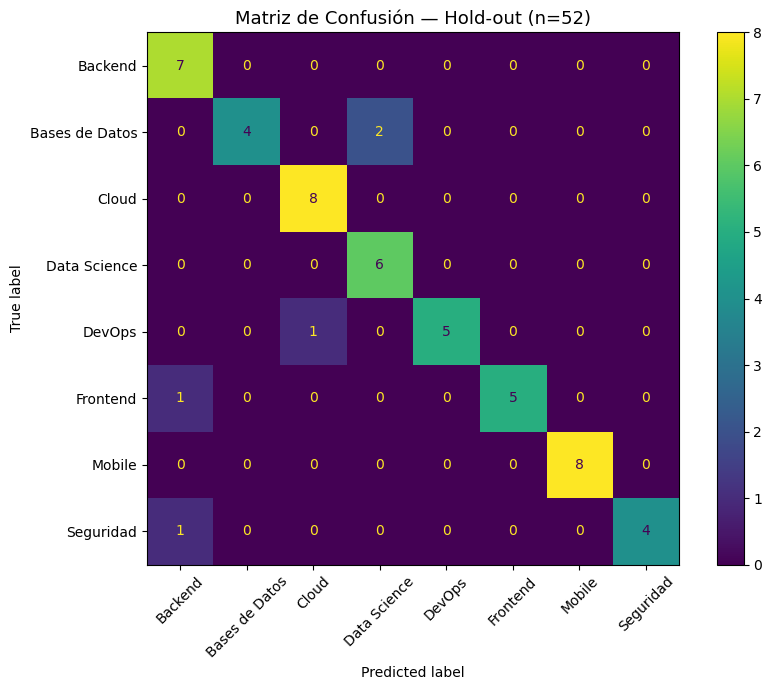

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    xticks_rotation=45,
    ax=ax,
    colorbar=True
)
ax.set_title(f"Matriz de Confusión — Hold-out (n={len(y_test)})", fontsize=13)
plt.tight_layout()
plt.show()


> **Nota:** con ~259 muestras el hold-out deja ~52 registros de test.
> Las métricas son más representativas que con 61 registros,
> pero la validación cruzada de la sección siguiente es aún más robusta.


## 9. Validación Cruzada Estratificada (K-Fold, K=5)

La **validación cruzada** usa el **100% de las muestras** para medir el rendimiento
del modelo, en lugar de depender de un único corte de datos.

Con `K=5` el dataset se divide en 5 particiones (*folds*). En cada iteración:
- 4 folds se usan para **entrenar**
- 1 fold se usa para **evaluar**

El proceso se repite 5 veces (una por fold) y el accuracy final es el promedio de los 5 resultados.

```
Fold 1: [EVAL][TRAIN][TRAIN][TRAIN][TRAIN] → acc₁
Fold 2: [TRAIN][EVAL][TRAIN][TRAIN][TRAIN] → acc₂
Fold 3: [TRAIN][TRAIN][EVAL][TRAIN][TRAIN] → acc₃
Fold 4: [TRAIN][TRAIN][TRAIN][EVAL][TRAIN] → acc₄
Fold 5: [TRAIN][TRAIN][TRAIN][TRAIN][EVAL] → acc₅
                                             ────
                                    Mean ± Std
```

`StratifiedKFold` garantiza que cada fold respete la proporción original de clases.


In [14]:
from sklearn.pipeline import Pipeline

# Armamos un Pipeline para que el vectorizador se re-fitee en cada fold
# (evita data leakage — el vocabulario TF-IDF no ve el fold de evaluación)
pipeline_cv = Pipeline([
    ("tfidf", TfidfVectorizer(
        sublinear_tf=True,
        ngram_range=(1, 3),
        min_df=1,
        max_df=0.90,
        max_features=6000
    )),
    ("clf", VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", C=1.5, random_state=42)),
            ("svc", CalibratedClassifierCV(
                estimator=LinearSVC(class_weight="balanced", max_iter=3000, random_state=42),
                cv=5, method="sigmoid"
            )),
            ("cnb", ComplementNB(alpha=0.5))
        ],
        voting="soft"
    ))
])

# StratifiedKFold: mantiene la proporción de clases en cada fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("⏳ Ejecutando Cross-Validation K=5 (esto puede tardar ~1-2 min)...")
cv_scores = cross_val_score(
    pipeline_cv,
    df["texto_limpio"],  # input crudo — el pipeline fitea TF-IDF en cada fold
    y,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

print(f"\n📊 Resultados de Cross-Validation (K=5):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f} ({s*100:.2f}%)")
print(f"\n✨ Accuracy CV promedio : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"   Desviación estándar  : ± {cv_scores.std():.4f}")
print(f"   Rango               : [{cv_scores.min():.4f} – {cv_scores.max():.4f}]")


⏳ Ejecutando Cross-Validation K=5 (esto puede tardar ~1-2 min)...



📊 Resultados de Cross-Validation (K=5):
  Fold 1: 0.8462 (84.62%)
  Fold 2: 0.8846 (88.46%)
  Fold 3: 0.9038 (90.38%)
  Fold 4: 0.8077 (80.77%)
  Fold 5: 0.9216 (92.16%)

✨ Accuracy CV promedio : 0.8728 (87.28%)
   Desviación estándar  : ± 0.0411
   Rango               : [0.8077 – 0.9216]


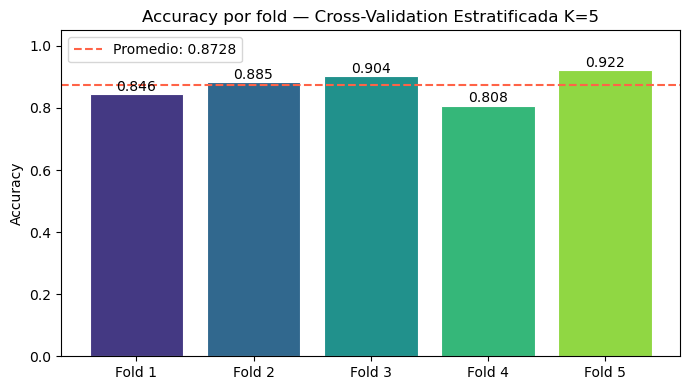

In [15]:
# Visualización de los scores por fold
plt.figure(figsize=(7, 4))
bars = plt.bar([f"Fold {i}" for i in range(1, 6)], cv_scores,
               color=sns.color_palette("viridis", 5), edgecolor="white", linewidth=0.8)
plt.axhline(cv_scores.mean(), color="tomato", linestyle="--", linewidth=1.5,
            label=f"Promedio: {cv_scores.mean():.4f}")
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Accuracy por fold — Cross-Validation Estratificada K=5", fontsize=12)
plt.legend()
for bar, score in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{score:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## 10. Extracción de palabras clave (`informaciones_adicionales`)

Las keywords se extraen por **peso TF-IDF dentro del propio documento**,
independientemente de la categoría predicha. Es lo que el back-end devuelve
en el campo `informaciones_adicionales`.


In [16]:
def extraer_keywords(texto_limpio: str, vec: TfidfVectorizer, top_n: int = 5):
    """Devuelve las top_n palabras/n-gramas con mayor peso TF-IDF en el documento."""
    vector = vec.transform([texto_limpio])
    feature_names = vec.get_feature_names_out()
    scores = vector.toarray()[0]
    top_indices = scores.argsort()[::-1][:top_n]
    return [feature_names[i] for i in top_indices if scores[i] > 0]

# Prueba rápida con el primer registro
ej = df.iloc[0]
print("Título  :", ej["titulo"])
print("Categoría:", ej["categoria"])
print("Keywords :", extraer_keywords(ej["texto_limpio"], vectorizer))


Título  : Introducción a Spring Boot
Categoría: Backend
Keywords : ['boot', 'spring boot', 'spring', 'boot contenido', 'contenido presentan']


## 11. Función de inferencia end-to-end

Replica lo que hace el endpoint `POST /contenido` de la API FastAPI.


In [17]:
def procesar_contenido(titulo: str, texto: str, top_n_keywords: int = 5) -> dict:
    """
    Recibe titulo + texto y devuelve categoria, probabilidad y keywords.
    Replica el comportamiento del endpoint POST /contenido de la API.
    """
    texto_completo = f"{titulo}. {texto}"
    texto_limpio = limpiar_texto(texto_completo)
    vector = vectorizer.transform([texto_limpio])

    categoria_predicha = ensamble.predict(vector)[0]
    probabilidades = ensamble.predict_proba(vector)[0]
    probabilidad = float(np.max(probabilidades))
    keywords = extraer_keywords(texto_limpio, vectorizer, top_n=top_n_keywords)

    return {
        "categoria": categoria_predicha,
        "probabilidad": round(probabilidad, 4),
        "informaciones_adicionales": keywords,
    }

# Ejemplo rápido
resultado = procesar_contenido(
    "Introducción a Spring Boot",
    "Conceptos básicos para la creación de APIs REST con Java y Spring Boot."
)
print(json.dumps(resultado, indent=2, ensure_ascii=False))


{
  "categoria": "Backend",
  "probabilidad": 0.7835,
  "informaciones_adicionales": [
    "boot",
    "spring boot",
    "spring",
    "apis rest",
    "java"
  ]
}


## 12. Tres ejemplos de uso documentados (requisito del MVP)


In [18]:
ejemplos = [
    {
        "titulo": "Introducción a Spring Boot",
        "texto": "Conceptos básicos para la creación de APIs REST con Java y Spring Boot.",
    },
    {
        "titulo": "Limpieza y transformación de datos",
        "texto": "Uso de Pandas para limpiar datos faltantes, normalizar columnas y preparar un dataset para modelado.",
    },
    {
        "titulo": "Despliegue de contenedores en producción",
        "texto": "Cómo construir imágenes Docker y orquestarlas con Kubernetes para un despliegue continuo escalable.",
    },
]

for ej in ejemplos:
    salida = procesar_contenido(ej["titulo"], ej["texto"])
    print("ENTRADA:", json.dumps(ej, ensure_ascii=False))
    print("SALIDA :", json.dumps(salida, ensure_ascii=False))
    print("-" * 80)


ENTRADA: {"titulo": "Introducción a Spring Boot", "texto": "Conceptos básicos para la creación de APIs REST con Java y Spring Boot."}
SALIDA : {"categoria": "Backend", "probabilidad": 0.7835, "informaciones_adicionales": ["boot", "spring boot", "spring", "apis rest", "java"]}
--------------------------------------------------------------------------------
ENTRADA: {"titulo": "Limpieza y transformación de datos", "texto": "Uso de Pandas para limpiar datos faltantes, normalizar columnas y preparar un dataset para modelado."}
SALIDA : {"categoria": "Data Science", "probabilidad": 0.4345, "informaciones_adicionales": ["limpieza transformación", "columnas", "transformación datos", "dataset", "datos faltantes"]}
--------------------------------------------------------------------------------
ENTRADA: {"titulo": "Despliegue de contenedores en producción", "texto": "Cómo construir imágenes Docker y orquestarlas con Kubernetes para un despliegue continuo escalable."}
SALIDA : {"categoria": "Dev

## 13. Re-entrenamiento final sobre el 100% del dataset y serialización

Para producción entrenamos el modelo final sobre **todos** los registros disponibles
(sin reservar hold-out), igual que hace `expand_and_train.py`.
Esto maximiza la cantidad de ejemplos vistos por el modelo en deployment.


In [19]:
MODELS_DIR = BASE_DIR / "models"
os.makedirs(MODELS_DIR, exist_ok=True)

print("🏋️  Entrenando modelo final sobre el 100% del dataset...")

# Nuevo vectorizer fitteado sobre todos los datos
vectorizer_final = TfidfVectorizer(
    sublinear_tf=True,
    ngram_range=(1, 3),
    min_df=1,
    max_df=0.90,
    max_features=6000
)
X_full = vectorizer_final.fit_transform(df["texto_limpio"])

modelo_final = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", C=1.5, random_state=42)),
        ("svc", CalibratedClassifierCV(
            estimator=LinearSVC(class_weight="balanced", max_iter=3000, random_state=42),
            cv=5, method="sigmoid"
        )),
        ("cnb", ComplementNB(alpha=0.5))
    ],
    voting="soft"
)
modelo_final.fit(X_full, y)

joblib.dump(vectorizer_final, MODELS_DIR / "tfidf_vectorizer.joblib")
joblib.dump(modelo_final,    MODELS_DIR / "modelo_clasificador.joblib")

print(f"💾 Artefactos guardados en: {MODELS_DIR}")
print("   tfidf_vectorizer.joblib")
print("   modelo_clasificador.joblib")


🏋️  Entrenando modelo final sobre el 100% del dataset...


💾 Artefactos guardados en: /Users/ernesto/Documents/GitHub/g9-latam-techmind-team37/data-science/models
   tfidf_vectorizer.joblib
   modelo_clasificador.joblib


## 14. Prueba de carga (simula el arranque de la API)

Verificamos que los artefactos `.joblib` se cargan correctamente y producen predicciones.


In [20]:
vec_cargado   = joblib.load(MODELS_DIR / "tfidf_vectorizer.joblib")
model_cargado = joblib.load(MODELS_DIR / "modelo_clasificador.joblib")

texto_prueba = limpiar_texto("Introducción a Spring Boot. APIs REST con Java y Spring Boot.")
vector_prueba = vec_cargado.transform([texto_prueba])

categoria = model_cargado.predict(vector_prueba)[0]
proba     = float(np.max(model_cargado.predict_proba(vector_prueba)))

print(f"✅ Carga de artefactos exitosa")
print(f"   Texto de prueba : 'Introducción a Spring Boot'")
print(f"   Categoría predicha: {categoria}")
print(f"   Probabilidad      : {proba:.4f}")


✅ Carga de artefactos exitosa
   Texto de prueba : 'Introducción a Spring Boot'
   Categoría predicha: Backend
   Probabilidad      : 0.8092


## 15. Resumen y próximos pasos

### Pipeline actual (producción)

```
CSV (259 registros)
  └─► titulo + texto  →  limpiar_texto()  →  TF-IDF (sublineal, 1-3 ngrams, 6000 feat)
        └─► Ensamble (LR + LinearSVC calibrado + ComplementNB)  →  .joblib
```

### Métricas obtenidas

| Evaluación | Accuracy |
|---|---|
| Hold-out 20% | ver Sección 8 |
| Cross-Val K=5 (promedio) | ver Sección 9 |

### Próximos pasos

- **Ampliar dataset**: agregar más registros por categoría (especialmente Mobile y Cloud)
  para mejorar la cobertura y reducir la varianza del CV
- **Hyperparameter tuning**: `GridSearchCV` sobre `C`, `alpha`, `max_features` usando el pipeline de CV
- **Subida a OCI Object Storage**: publicar los `.joblib` para que el back-end (FastAPI) los descargue al arrancar
- **Monitoreo de drift**: registrar predicciones reales vs. etiquetas aceptadas por usuarios para detectar degradación del modelo
